In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
customer = pd.read_csv('final_merged_df.csv')
transactions = pd.read_csv('transactions_grouped.csv')

In [7]:
sessions = pd.read_csv('session_grouped_all.csv')
sessions_top5 = pd.read_csv('session_grouped_top5.csv')
customer_top5 = pd.read_csv('customer_top5.csv')

In [31]:
customer_top5.head()

,machine_id,avg_basket_price,sum_basket_price,avg_product_price,sum_product_price,avg_product_qty,sum_pdt_qty,num_successful_transactions,num_total_sessions,total_weekday_sessions,...,hoh_oldest_age,household_income,children,racial_background,connection_speed,hispanic,census_region,zip_code,num_unique_categories,item_cat_OTHERS
0,54388726,0.000000,0.00,0.000000,0.00,0.000000,0.0,0,6,6,...,5.0,16.0,0.0,1.0,0.0,1.0,3.0,33130.0,0,0
1,76893652,0.000000,0.00,0.000000,0.00,0.000000,0.0,0,54,54,...,7.0,13.0,1.0,1.0,1.0,0.0,1.0,6058.0,0,0
2,84499675,0.000000,0.00,0.000000,0.00,0.000000,0.0,0,3,3,...,11.0,16.0,1.0,5.0,0.0,0.0,1.0,7601.0,0,0
3,98480988,0.000000,0.00,0.000000,0.00,0.000000,0.0,0,187,187,...,11.0,14.0,1.0,1.0,1.0,0.0,1.0,2871.0,0,0
4,100026976,0.119145,129.63,0.100836,109.71,0.002757,3.0,3,1088,1088,...,11.0,15.0,0.0,1.0,1.0,0.0,3.0,31405.0,1,0


In [30]:
transactions.head()

,Unnamed: 0,machine_id,transaction_datetime_x,basket_tot,prod_totprice,prod_qty,prod_category_id,pages_viewed,duration,transaction_hour,transaction_dayofweek,is_weekend,site_session_id
0,0,100026976,2022-10-17 03:09:26,129.63,109.71,3.0,1,22.0,29.0,3,0,0,7757747425267377381
1,1,104679635,2022-05-19 08:54:45,44.04,29.95,1.0,1,3.0,1.0,8,3,0,2961291707642428989
2,2,123005549,2023-03-14 15:47:05,15.55,14.58,1.0,1,15.0,53.0,15,1,0,1391366339713378262
3,3,123005549,2023-03-23 15:44:40,341.10,319.90,2.0,1,16.0,69.0,15,3,0,3556845585233678636
4,4,123005549,2023-04-18 16:40:26,42.64,39.99,1.0,1,9.0,16.0,16,1,0,2520119805771979145


# Stats

In [28]:
print(len(customer))
print(len(transactions))
print(len(sessions))

101426
147947
2771371


In [32]:
# people with successful transactions 
len(customer[customer['num_successful_transactions'] != 0])

19635

In [36]:
browsers = customer[customer['num_successful_transactions'] == 0]
buyers = customer[customer['num_successful_transactions'] != 0]

In [37]:
avg_sessions_browsers = browsers['num_total_sessions'].mean()
avg_sessions_buyers = buyers['num_total_sessions'].mean()


print(f"🧭 Browsers: {avg_sessions_browsers:.2f} sessions on average")
print(f"🛒 Buyers:   {avg_sessions_buyers:.2f} sessions on average")

🧭 Browsers: 8.58 sessions on average
🛒 Buyers:   115.29 sessions on average


In [38]:
buyers['sessions_per_purchase'] = buyers['num_total_sessions'] / buyers['num_successful_transactions']

# Average across all buyers
avg_sessions_per_purchase = buyers['sessions_per_purchase'].mean()

print(f"🛒 On average, buyers browse {avg_sessions_per_purchase:.2f} sessions per purchase")

🛒 On average, buyers browse 11.62 sessions per purchase


C:\Users\knich\AppData\Local\Temp\ipykernel_1772\2844479080.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  buyers['sessions_per_purchase'] = buyers['num_total_sessions'] / buyers['num_successful_transactions']


# Vizs

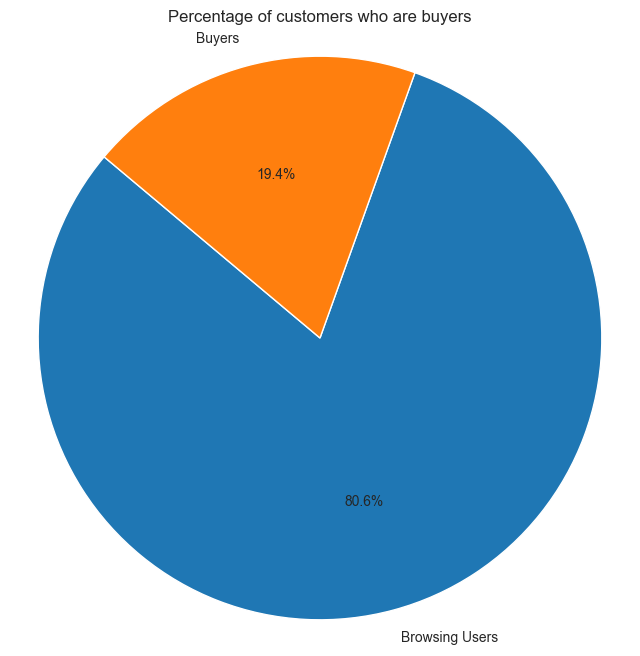

In [35]:
labels = ['Browsing Users', 'Buyers']
sizes = [101426-19635, 19635]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Percentage of customers who are buyers')
plt.axis('equal')
plt.show()

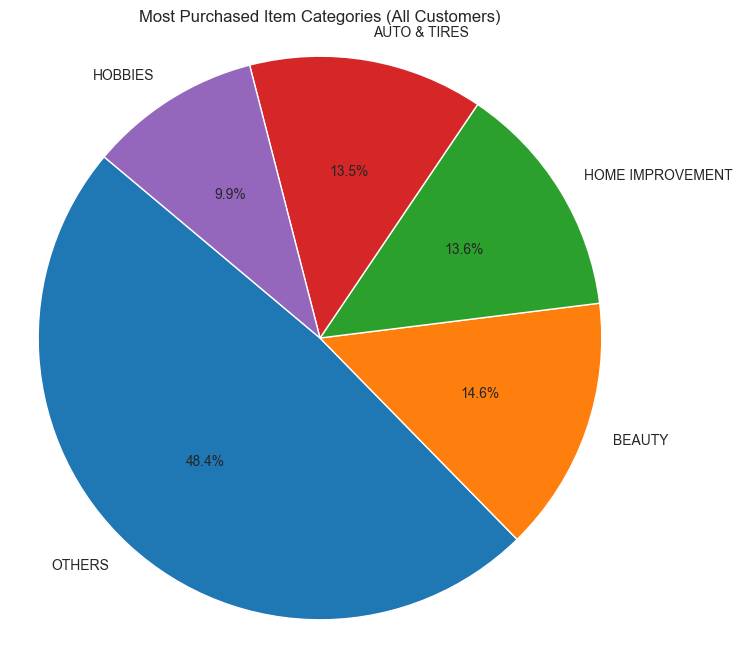

In [9]:
item_cat_cols = [col for col in customer_top5.columns if col.startswith('item_cat_')]

# Step 2: Total counts across all customers
cat_totals = customer_top5[item_cat_cols].sum().sort_values(ascending=False)

# Step 3: Format labels (remove prefix for readability)
labels = [col.replace('item_cat_', '') for col in cat_totals.index]
sizes = cat_totals.values

# Step 4: Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Most Purchased Item Categories (All Customers)')
plt.axis('equal')
plt.show()

In [21]:
customer.columns

Index(['machine_id', 'avg_basket_price', 'sum_basket_price',
       'avg_product_price', 'sum_product_price', 'avg_product_qty',
       'sum_pdt_qty', 'num_successful_transactions', 'num_total_sessions',
       'total_weekday_sessions', 'total_weekend_sessions',
       'num_unsuccessful_sessions', 'conversion_rate', 'item_cat_APPAREL',
       'item_cat_APPLIANCES', 'item_cat_ARTS & CRAFTS',
       'item_cat_AUTO & TIRES', 'item_cat_BABY', 'item_cat_BAGS & ACCESSORIES',
       'item_cat_BEAUTY', 'item_cat_BEDDING, BATH, & DECOR', 'item_cat_BOOKS',
       'item_cat_CAMERAS & CAMCORDERS', 'item_cat_COMPUTERS & PRINTERS',
       'item_cat_ELECTRONICS ACCESSORIES', 'item_cat_FLOWERS & GIFTS',
       'item_cat_FOOD & BEVERAGE', 'item_cat_FURNITURE & STORAGE',
       'item_cat_HEALTH', 'item_cat_HOBBIES', 'item_cat_HOME IMPROVEMENT',
       'item_cat_HOME THEATER',
       'item_cat_HOUSEHOLD ESSENTIALS & CLEANING SUPPLIES', 'item_cat_JEWELRY',
       'item_cat_KITCHEN & DINING', 'item_cat_LAW

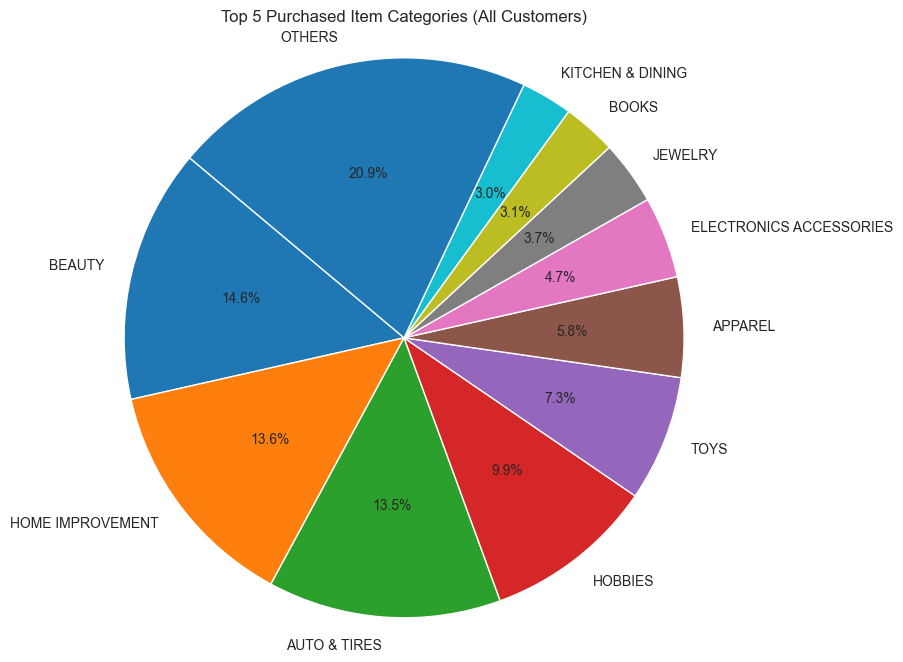

In [108]:
item_cat_cols = [col for col in customer.columns if col.startswith('item_cat_') and 'NAN' not in col.upper()]

# Step 2: Total count per category
cat_totals = customer[item_cat_cols].sum().sort_values(ascending=False)

# Step 3: Get top 10 categories and compute others
top10 = cat_totals.head(10)
others_sum = cat_totals.iloc[10:].sum()

if pd.isna(others_sum) or np.isinf(others_sum):
    others_sum = 0

# Step 4: Combine labels and sizes
labels = top10.index.tolist() + ['item_cat_OTHERS']
sizes = top10.values.tolist() + [others_sum]

# Clean up and filter
labels = [label.replace('item_cat_', '') for label in labels]
sizes = np.array(sizes)
labels = np.array(labels)
valid = np.isfinite(sizes) & (sizes > 0)
sizes = sizes[valid]
labels = labels[valid]

# Step 5: Plot
plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Top 5 Purchased Item Categories (All Customers)')
plt.axis('equal')
plt.show()

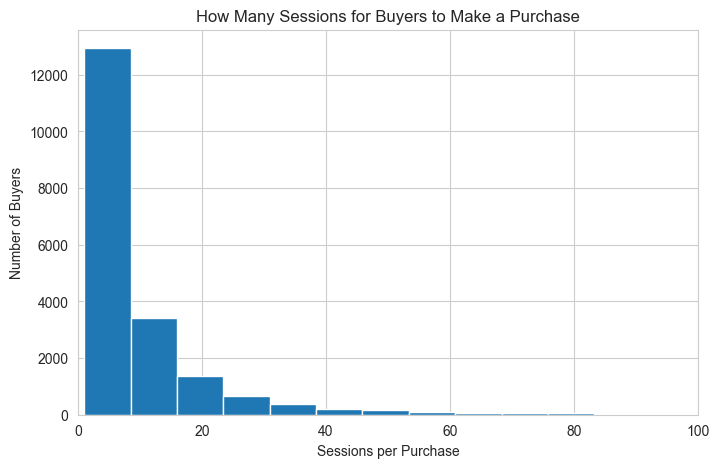

In [47]:
plt.figure(figsize=(8, 5))
buyers['sessions_per_purchase'].hist(bins=200)
plt.xlabel('Sessions per Purchase')
plt.xlim(0, 100)
plt.ylabel('Number of Buyers')
plt.title('How Many Sessions for Buyers to Make a Purchase')
plt.grid(True)
plt.show()

In [66]:
def plot_demo_distribution(col, browsers_df=browsers, buyers_df=buyers, label_map=None):
    """
    Plots % distribution of a demographic column for buyers vs browsers, with optional label mapping.

    Parameters:
    - col (str): column name (e.g., 'household_income')
    - browsers_df (DataFrame): browser-level customer data
    - buyers_df (DataFrame): buyer-level customer data
    - label_map (dict): optional mapping of coded values to labels
    """
    # Get raw value counts
    dist_browsers = browsers_df[col].value_counts(normalize=True).sort_index()
    dist_buyers = buyers_df[col].value_counts(normalize=True).sort_index()

    # Combine
    dist_df = pd.DataFrame({'Browsers': dist_browsers, 'Buyers': dist_buyers}).fillna(0) * 100

    # Replace index with readable labels if provided
    if label_map:
        dist_df.index = dist_df.index.map(label_map)

    # Plot
    dist_df.plot(kind='bar', figsize=(10, 5))
    plt.title(f'{col.replace("_", " ").title()} Distribution (% of Users)')
    plt.ylabel('% of Users')
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

In [69]:
income_map = {
    11: '<$25K', 12: '$25K–$40K', 13: '$40K–$60K',
    14: '$60K–$75K', 15: '$75K–$100K', 16: '$100K–$150K',
    17: '$150K–$200K', 18: '$200K+', 99: 'Unknown'
}

age_map = {
    1: '18–20', 2: '21–24', 3: '25–29', 4: '30–34',
    5: '35–39', 6: '40–44', 7: '45–49', 8: '50–54',
    9: '55–59', 10: '60–64', 11: '65+', 99: 'Unknown'
}

hh_size_map = {
    1: '1', 2: '2', 3: '3', 4: '4', 5: '5+', 99: 'Unknown', -88: 'Unknown'
}

racial_map = {
    1: 'Caucasian', 2: 'African American', 3: 'Asian', 4: 'Other', 5:'Unknown'
}


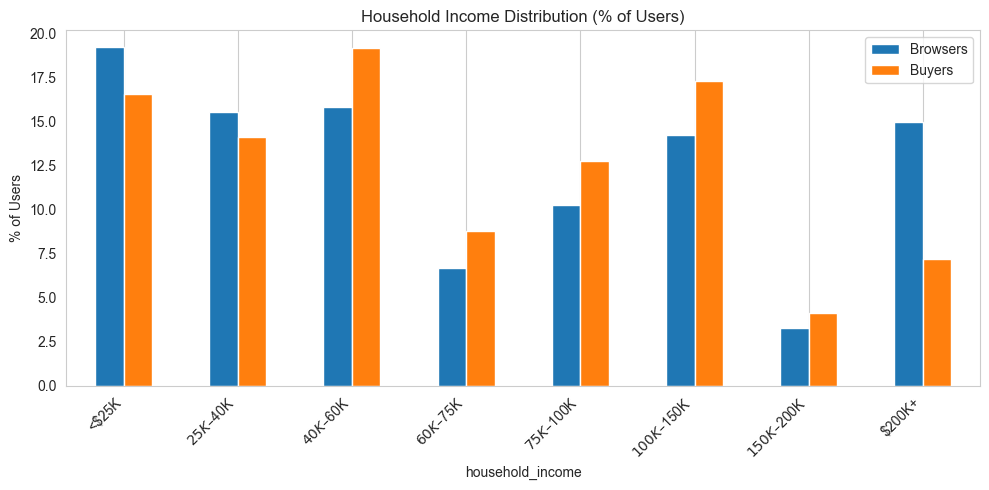

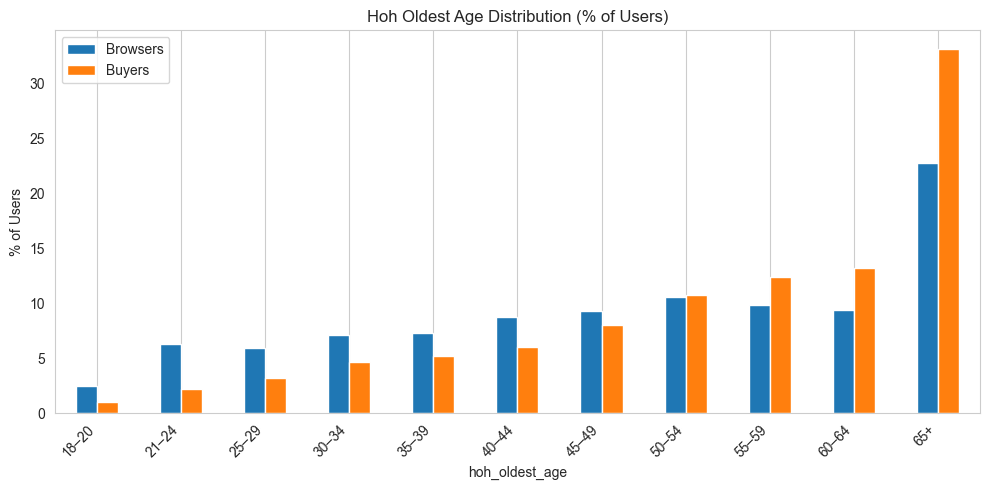

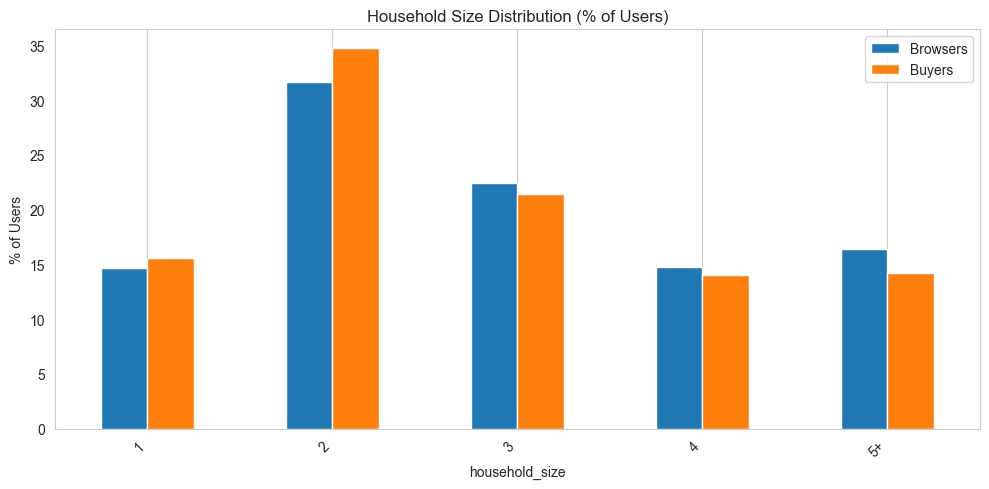

In [68]:
plot_demo_distribution('household_income', browsers, buyers, income_map)
plot_demo_distribution('hoh_oldest_age', browsers, buyers, label_map=age_map)
plot_demo_distribution('household_size', browsers, buyers, label_map=hh_size_map)

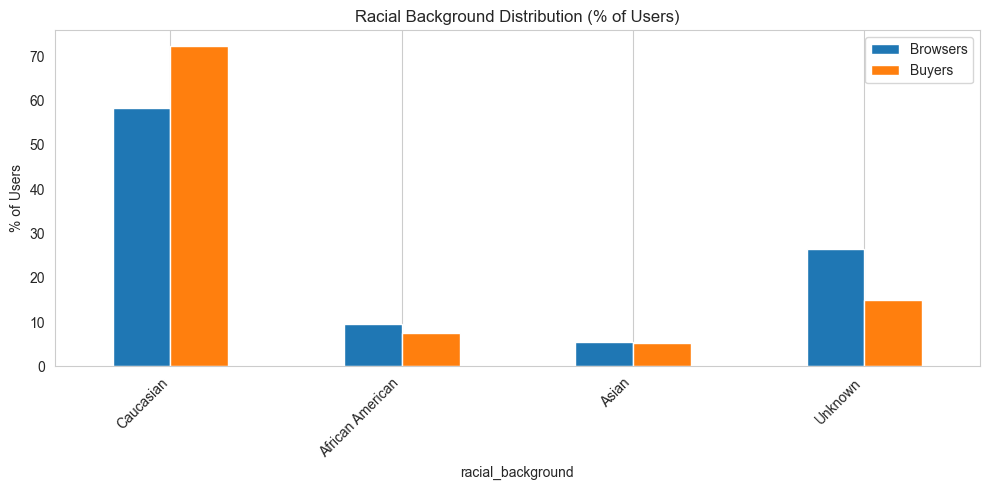

In [71]:
plot_demo_distribution(col = 'racial_background', browsers_df = browsers, buyers_df = buyers, label_map = racial_map)

In [81]:
low_income = customer[customer['household_income'].isin([11, 12])]
mid_income = customer[customer['household_income'].isin([13, 14, 15, 16, 17])]
high_income = customer[customer['household_income'] == 18]

item_cat_cols = [col for col in customer.columns if col.startswith('item_cat_')]

low_income_totals = low_income[item_cat_cols].sum().sort_values(ascending=False)
mid_income_totals = mid_income[item_cat_cols].sum().sort_values(ascending = False)
high_income_totals = high_income[item_cat_cols].sum().sort_values(ascending=False)

purchase_compare = pd.DataFrame({
    'Low Income (<$40K)': low_income_totals,
    'Mid Income (\$40K - \$200k)': mid_income_totals,
    'High Income (>$200K)': high_income_totals
}).fillna(0)

# Normalize to % within group
purchase_compare_pct = purchase_compare.div(purchase_compare.sum(axis=0), axis=1) * 100

<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:13: SyntaxWarning: invalid escape sequence '\$'
C:\Users\knich\AppData\Local\Temp\ipykernel_1772\3411966052.py:13: SyntaxWarning: invalid escape sequence '\$'
  'Mid Income (\$40K - \$200k)': mid_income_totals,


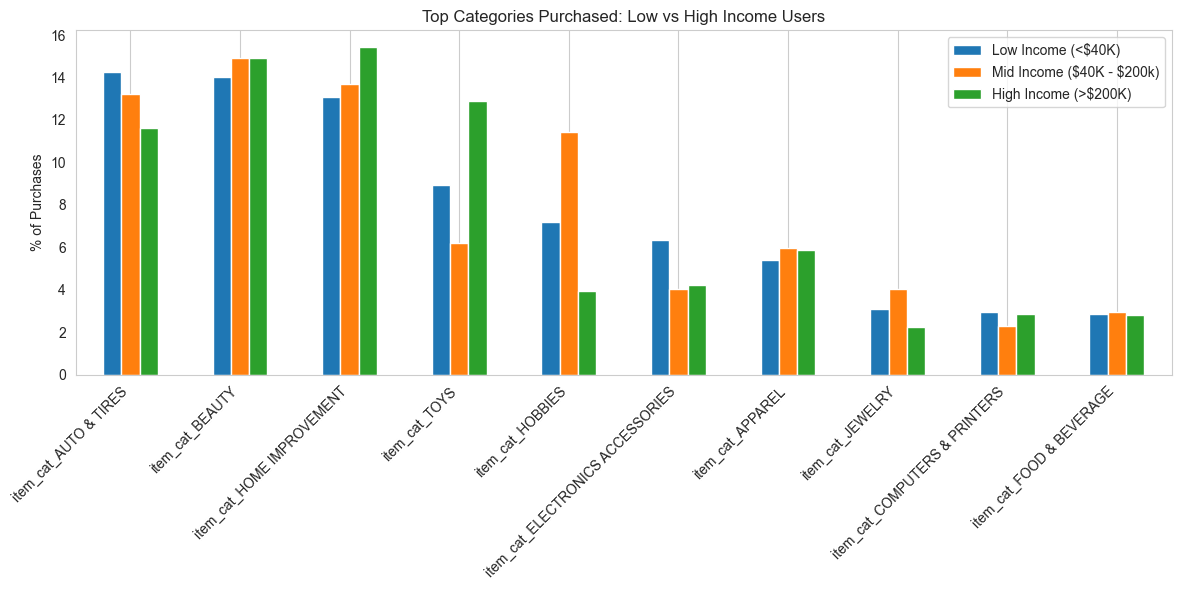

In [82]:
purchase_compare_pct.sort_values('Low Income (<$40K)', ascending=False).head(10).plot(
    kind='bar', figsize=(12, 6)
)
plt.ylabel('% of Purchases')
plt.title('Top Categories Purchased: Low vs High Income Users')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

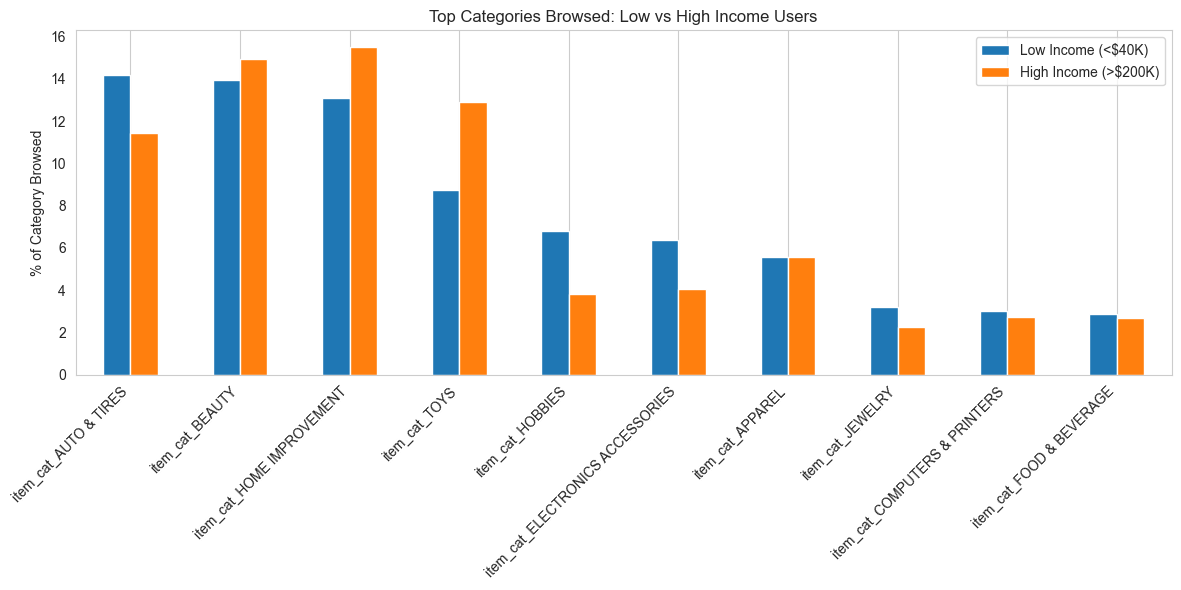

In [77]:
low_income_sessions = sessions[sessions['household_income'].isin([11, 12])]
high_income_sessions = sessions[sessions['household_income'] == 18]

item_cat_cols = [col for col in sessions.columns if col.startswith('item_cat_') and 'NAN' not in col.upper()]

low_browse = low_income_sessions[item_cat_cols].sum().sort_values(ascending=False)
high_browse = high_income_sessions[item_cat_cols].sum().sort_values(ascending=False)

browse_compare = pd.DataFrame({
    'Low Income (<$40K)': low_browse,
    'High Income (>$200K)': high_browse
}).fillna(0)

# Normalize to % of total browsed per group
browse_compare_pct = browse_compare.div(browse_compare.sum(axis=0), axis=1) * 100

browse_compare_pct.sort_values('Low Income (<$40K)', ascending=False).head(10).plot(
    kind='bar', figsize=(12, 6)
)
plt.ylabel('% of Category Browsed')
plt.title('Top Categories Browsed: Low vs High Income Users')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [78]:
buyers.columns

Index(['machine_id', 'avg_basket_price', 'sum_basket_price',
       'avg_product_price', 'sum_product_price', 'avg_product_qty',
       'sum_pdt_qty', 'num_successful_transactions', 'num_total_sessions',
       'total_weekday_sessions', 'total_weekend_sessions',
       'num_unsuccessful_sessions', 'conversion_rate', 'item_cat_APPAREL',
       'item_cat_APPLIANCES', 'item_cat_ARTS & CRAFTS',
       'item_cat_AUTO & TIRES', 'item_cat_BABY', 'item_cat_BAGS & ACCESSORIES',
       'item_cat_BEAUTY', 'item_cat_BEDDING, BATH, & DECOR', 'item_cat_BOOKS',
       'item_cat_CAMERAS & CAMCORDERS', 'item_cat_COMPUTERS & PRINTERS',
       'item_cat_ELECTRONICS ACCESSORIES', 'item_cat_FLOWERS & GIFTS',
       'item_cat_FOOD & BEVERAGE', 'item_cat_FURNITURE & STORAGE',
       'item_cat_HEALTH', 'item_cat_HOBBIES', 'item_cat_HOME IMPROVEMENT',
       'item_cat_HOME THEATER',
       'item_cat_HOUSEHOLD ESSENTIALS & CLEANING SUPPLIES', 'item_cat_JEWELRY',
       'item_cat_KITCHEN & DINING', 'item_cat_LAW

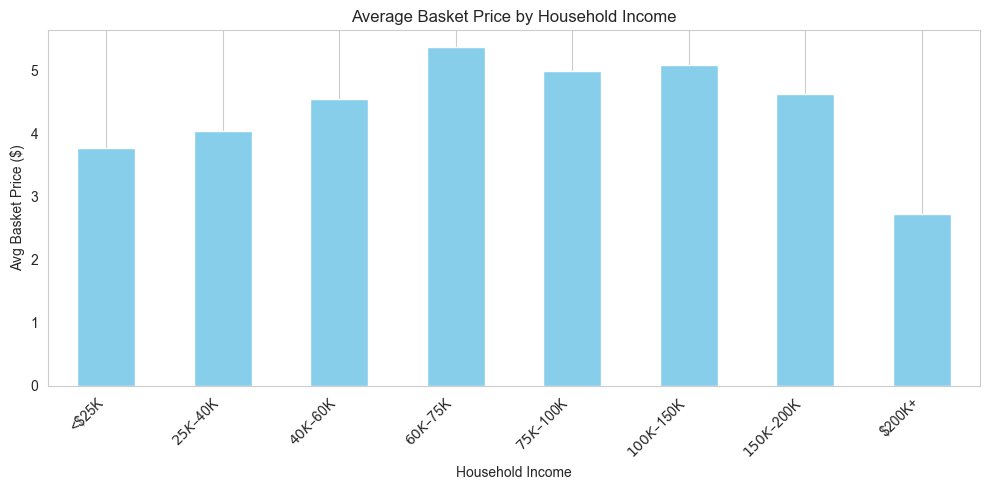

In [83]:
basket_by_income = customer.groupby('household_income')['avg_basket_price'].mean().sort_index()

# Optional: apply income label mapping
income_map = {
    11: '<$25K', 12: '$25K–$40K', 13: '$40K–$60K',
    14: '$60K–$75K', 15: '$75K–$100K', 16: '$100K–$150K',
    17: '$150K–$200K', 18: '$200K+', 99: 'Unknown'
}
basket_by_income.index = basket_by_income.index.map(income_map)

# Plot
plt.figure(figsize=(10, 5))
basket_by_income.plot(kind='bar', color='skyblue')
plt.title('Average Basket Price by Household Income')
plt.xlabel('Household Income')
plt.ylabel('Avg Basket Price ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

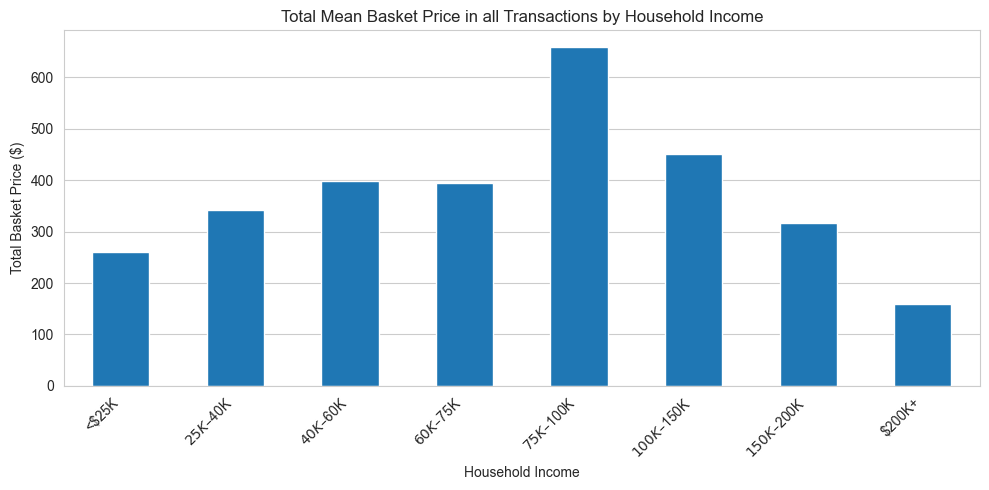

In [94]:
basket_by_income = customer.groupby('household_income')['sum_basket_price'].mean().sort_index()

# Optional: apply income label mapping
income_map = {
    11: '<$25K', 12: '$25K–$40K', 13: '$40K–$60K',
    14: '$60K–$75K', 15: '$75K–$100K', 16: '$100K–$150K',
    17: '$150K–$200K', 18: '$200K+', 99: 'Unknown'
}
basket_by_income.index = basket_by_income.index.map(income_map)

# Plot
plt.figure(figsize=(10, 5))
basket_by_income.plot(kind='bar')
plt.title('Total Mean Basket Price in all Transactions by Household Income')
plt.xlabel('Household Income')
plt.ylabel('Total Basket Price ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis = 'x')
plt.tight_layout()
plt.show()

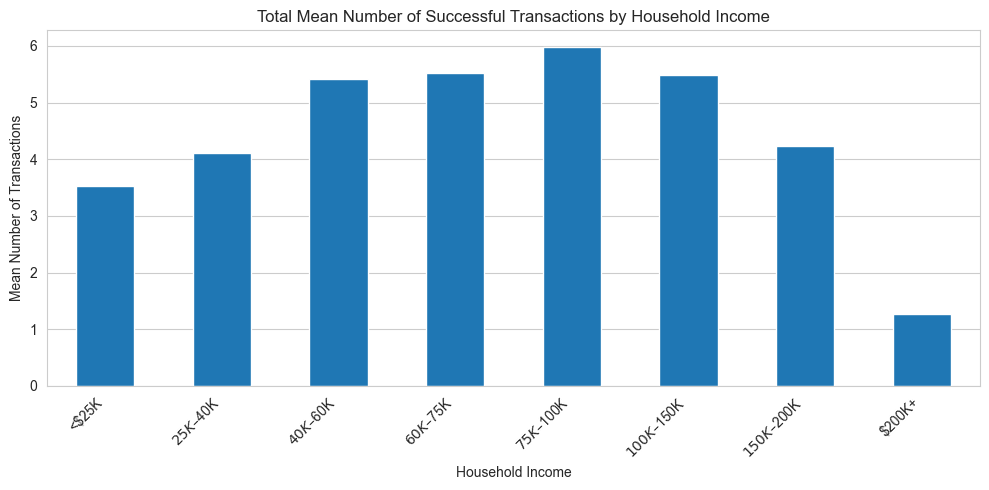

In [106]:
basket_by_income = customer.groupby('household_income')['num_successful_transactions'].mean().sort_index()

# Optional: apply income label mapping
income_map = {
    11: '<$25K', 12: '$25K–$40K', 13: '$40K–$60K',
    14: '$60K–$75K', 15: '$75K–$100K', 16: '$100K–$150K',
    17: '$150K–$200K', 18: '$200K+', 99: 'Unknown'
}
basket_by_income.index = basket_by_income.index.map(income_map)

# Plot
plt.figure(figsize=(10, 5))
basket_by_income.plot(kind='bar')
plt.title('Total Mean Number of Successful Transactions by Household Income')
plt.xlabel('Household Income')
plt.ylabel('Mean Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.grid(axis = 'x')
plt.tight_layout()
plt.show()

# Cluster analysis 

In [109]:
c1 = pd.read_csv('cluster_1_df.csv')
c2 = pd.read_csv('cluster_2_df.csv')
c3 = pd.read_csv('cluster_3_df.csv')
c4 = pd.read_csv('cluster_4_df.csv')

In [110]:
c1.head()

,machine_id,cluster,site_session_id,pages_viewed,duration,avg_time_second_per_page,pages_per_second,is_transacted,household_size,hoh_oldest_age,...,item_cat_JEWELRY,item_cat_BOOKS,race_Caucasian,race_Other,race_African_American,race_Asian,region_South,region_North_East,region_North_Central,region_West
0,164363827,1,1.735763e+15,3,12,240.000000,0.004167,1,5,9,...,0,0,1,0,0,0,0,1,0,0
1,164363827,1,1.021845e+16,17,24,84.705882,0.011806,0,5,9,...,0,0,1,0,0,0,0,1,0,0
2,164363827,1,2.546666e+16,15,61,244.000000,0.004098,0,5,9,...,0,0,1,0,0,0,0,1,0,0
3,164363827,1,3.688383e+16,6,9,90.000000,0.011111,0,5,9,...,0,0,1,0,0,0,0,1,0,0
4,164363827,1,3.722648e+16,17,33,116.470588,0.008586,0,5,9,...,0,0,1,0,0,0,0,1,0,0


In [116]:
def plot_demo_distribution(col, df1, df2, df3, df4, label_map=None):
    """
    Plots % distribution of a demographic column for buyers vs browsers, with optional label mapping.

    Parameters:
    - col (str): column name (e.g., 'household_income')
    - browsers_df (DataFrame): browser-level customer data
    - buyers_df (DataFrame): buyer-level customer data
    - label_map (dict): optional mapping of coded values to labels
    """
    # Get raw value counts
    dist_df1 = df1[col].value_counts(normalize=True).sort_index()
    dist_df2 = df2[col].value_counts(normalize=True).sort_index()
    dist_df3 = df3[col].value_counts(normalize=True).sort_index()
    dist_df4 = df4[col].value_counts(normalize=True).sort_index()

    # Combine
    dist_df = pd.DataFrame({'Cluster 1': dist_df1, 'Cluster 2': dist_df2, 'Cluster 3': dist_df3, 'Cluster 4': dist_df4}).fillna(0) * 100

    # Replace index with readable labels if provided
    if label_map:
        dist_df.index = dist_df.index.map(label_map)

    # Plot
    dist_df.plot(kind='bar', figsize=(10, 5))
    plt.title(f'{col.replace("_", " ").title()} Distribution (% of Users)')
    plt.ylabel('% of Users')
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

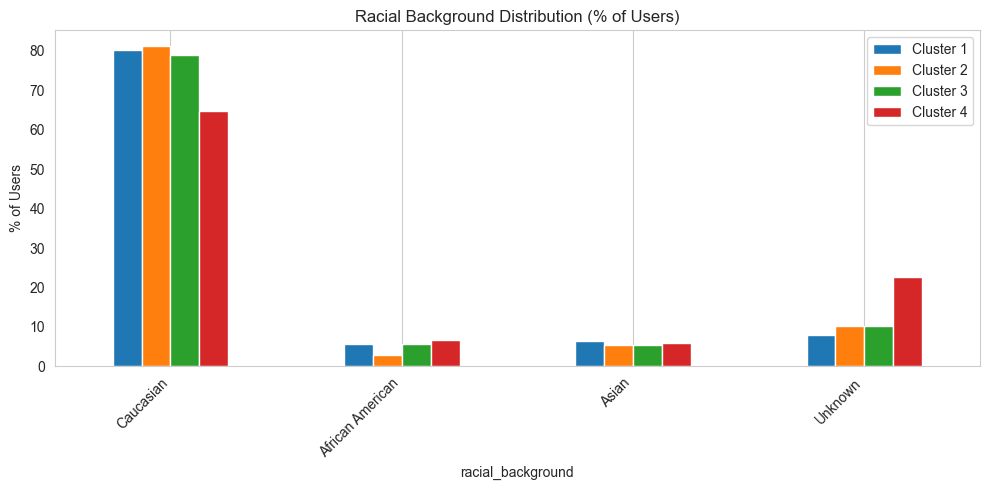

In [127]:
plot_demo_distribution(col = 'racial_background', df1 = c1, df2 = c2, df3 = c3, df4 = c4, label_map = racial_map)

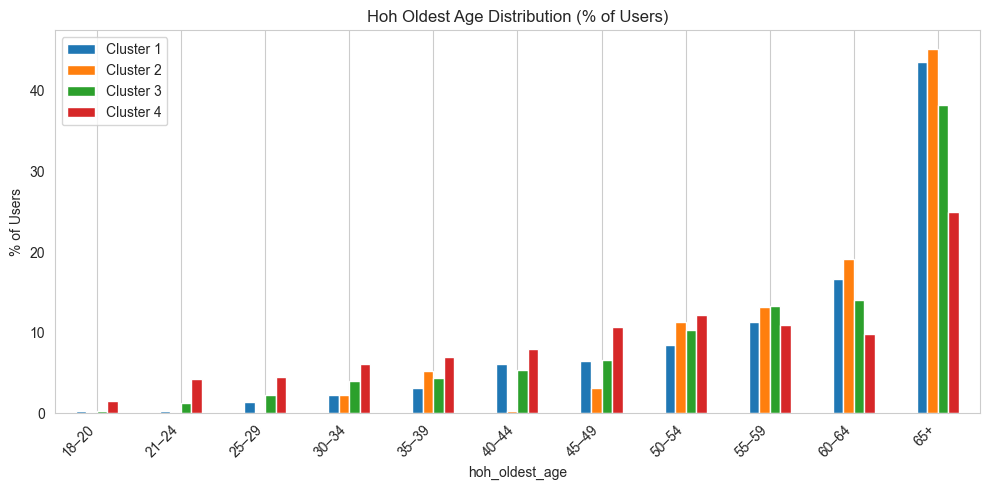

In [128]:
plot_demo_distribution(col = 'hoh_oldest_age', df1 = c1, df2 = c2, df3 = c3, df4 = c4, label_map = age_map)

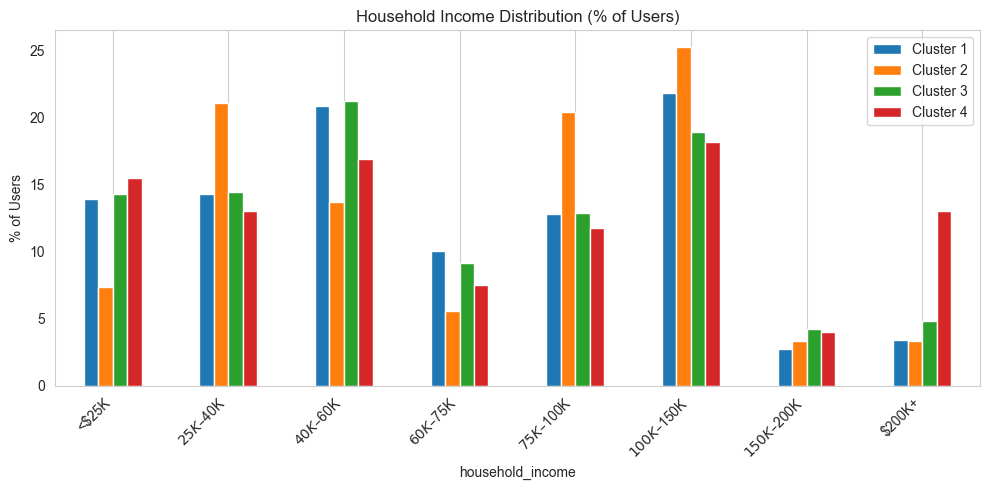

In [129]:
plot_demo_distribution(col = 'household_income', df1 = c1, df2 = c2, df3 = c3, df4 = c4, label_map = income_map)

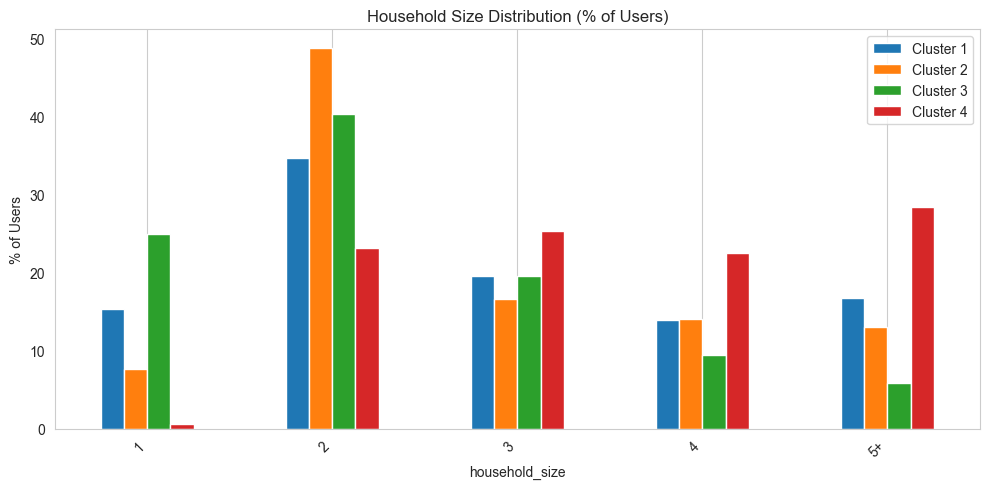

In [130]:
plot_demo_distribution(col = 'household_size', df1 = c1, df2 = c2, df3 = c3, df4 = c4, label_map = hh_size_map)

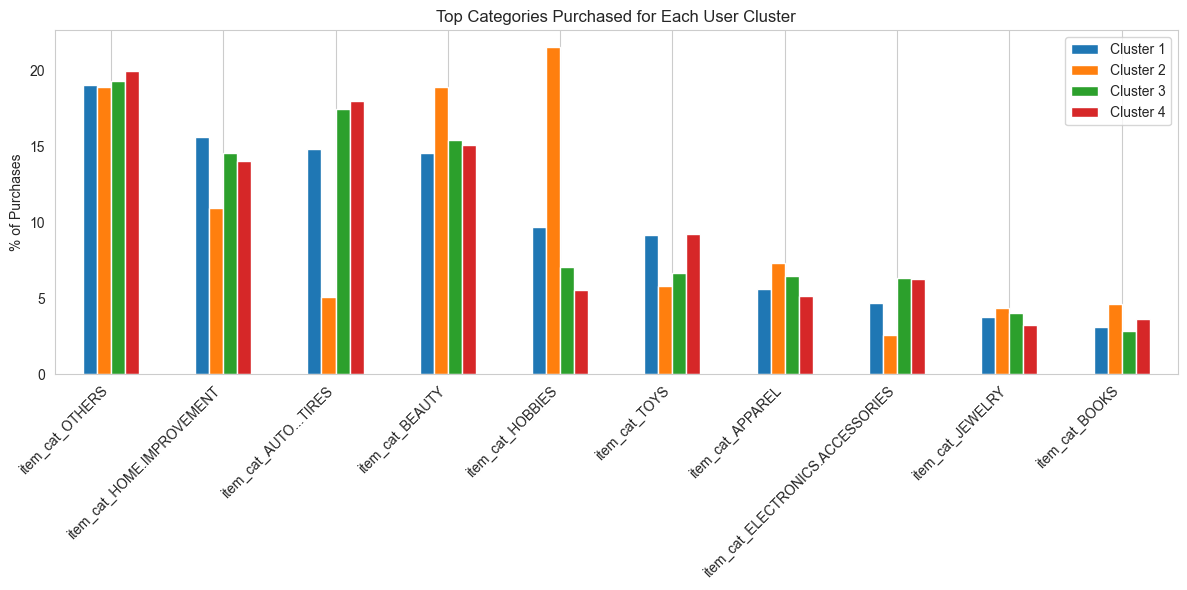

In [133]:
item_cat_cols = [col for col in c1.columns if col.startswith('item_cat_')]

c1_totals = c1[item_cat_cols].sum().sort_values(ascending=False)
c2_totals = c2[item_cat_cols].sum().sort_values(ascending = False)
c3_totals = c3[item_cat_cols].sum().sort_values(ascending=False)
c4_totals = c4[item_cat_cols].sum().sort_values(ascending=False)

purchase_compare = pd.DataFrame({
    'Cluster 1': c1_totals,
    'Cluster 2': c2_totals,
    'Cluster 3': c3_totals, 
    'Cluster 4': c4_totals
}).fillna(0)

# Normalize to % within group
purchase_compare_pct = purchase_compare.div(purchase_compare.sum(axis=0), axis=1) * 100

purchase_compare_pct.sort_values('Cluster 1', ascending=False).head(10).plot(
    kind='bar', figsize=(12, 6)
)
plt.ylabel('% of Purchases')
plt.title('Top Categories Purchased for Each User Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

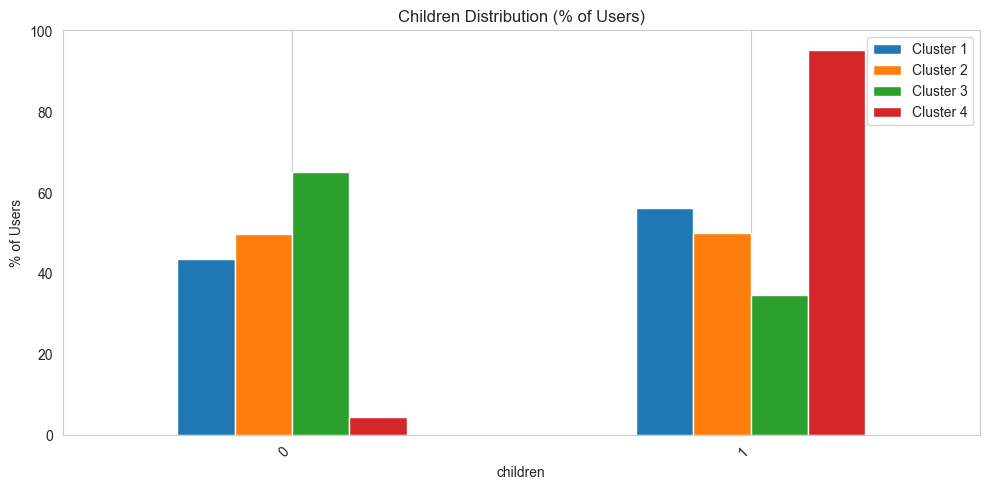

In [132]:
plot_demo_distribution(col = 'children', df1 = c1, df2 = c2, df3 = c3, df4 = c4)